In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt

In [2]:
# load the data
data = pd.read_csv("covtype.data", header = None)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values 

# convert the labels from [1...7] to [0...6]
y = y - 1

# shape of the data
print("Dataset shape:", X.shape)

Dataset shape: (581012, 54)


In [3]:
print("Unique labels:", np.unique(y))
print("Label counts:\n", pd.Series(y).value_counts())

Unique labels: [0 1 2 3 4 5 6]
Label counts:
 1    283301
0    211840
2     35754
6     20510
5     17367
4      9493
3      2747
Name: count, dtype: int64


In [4]:
# TRAIN - VAL - TEST split 
# Splitting train & test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Splitting train & validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size = 0.1, random_state = 42, stratify = y_temp)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (418328, 54)
Validation: (46481, 54)
Test: (116203, 54)


In [5]:
# feature scaling 
# scaler = StandardScaler(with_mean = False)
scaler = MaxAbsScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

poly = PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False
)

X_train = poly.fit_transform(X_train)
X_val = poly.transform(X_val)
X_test = poly.transform(X_test)
print("New feature shape:", X_train.shape)

New feature shape: (418328, 1485)


In [6]:
# one-versus-rest lSVM model
class OneVsRestLSVM:
    def __init__(self, C = 1.0):
        self.C = C
        self.models = []
        self.num_classes = None

    def fit(self, X, y):
        self.num_classes = len(np.unique(y))
        self.models = []

        for c in range(self.num_classes):
            print("Training classifier for class", c, "vs. rest")

            # make binary labels
            y_binary = np.where(y == c, 1, -1)

            model = LinearSVC(C = self.C, max_iter = 10000, dual = False)
            model.fit(X, y_binary)

            self.models.append(model)

    def decision_function(self, X):
        scores = []

        for model in self.models:
            scores.append(model.decision_function(X))

        return np.vstack(scores).T

    def predict(self, X):
        scores = self.decision_function(X)
        return np.argmax(scores, axis = 1)

In [7]:
# evaluation function
def evaluate(model, X, y, name = "Dataset"):
    y_pred = model.predict(X)

    acc = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, average = 'weighted')
    recall = recall_score(y, y_pred, average = 'weighted')
    f1 = f1_score(y, y_pred, average = 'weighted')

    print(name, "Results:")
    print("Accuracy: %.4f" % acc)
    print("Precision: %.4f" % precision)
    print("Recall: %.4f" % recall)
    print("F1 score: %.4f" % f1)
    print("\n--------------\n")

    return acc, f1

In [8]:
# training the model
C_values = [0.1, 1, 10]

train_accs = []
val_accs = []
test_accs = []

train_f1s = []
val_f1s = []
test_f1s = []

for C in C_values:
    print(f"\nTraining with C = {C}")
    
    model = OneVsRestLSVM(C=C)
    model.fit(X_train, y_train)
    
    train_acc, train_f1 = evaluate(model, X_train, y_train, f"Train (C={C})")
    val_acc, val_f1 = evaluate(model, X_val, y_val, f"Validation (C={C})")
    test_acc, test_f1 = evaluate(model, X_test, y_test, f"Test (C={C})")

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    test_accs.append(test_acc)

    train_f1s.append(train_f1)
    val_f1s.append(val_f1)
    test_f1s.append(test_f1)


Training with C = 0.1
Training classifier for class 0 vs. rest
Training classifier for class 1 vs. rest
Training classifier for class 2 vs. rest
Training classifier for class 3 vs. rest
Training classifier for class 4 vs. rest
Training classifier for class 5 vs. rest
Training classifier for class 6 vs. rest
Train (C=0.1) Results:
Accuracy: 0.7552
Precision: 0.7527
Recall: 0.7552
F1 score: 0.7477

--------------

Validation (C=0.1) Results:
Accuracy: 0.7530
Precision: 0.7505
Recall: 0.7530
F1 score: 0.7452

--------------

Test (C=0.1) Results:
Accuracy: 0.7541
Precision: 0.7515
Recall: 0.7541
F1 score: 0.7467

--------------


Training with C = 1
Training classifier for class 0 vs. rest
Training classifier for class 1 vs. rest
Training classifier for class 2 vs. rest
Training classifier for class 3 vs. rest
Training classifier for class 4 vs. rest
Training classifier for class 5 vs. rest
Training classifier for class 6 vs. rest
Train (C=1) Results:
Accuracy: 0.7628
Precision: 0.7608
R

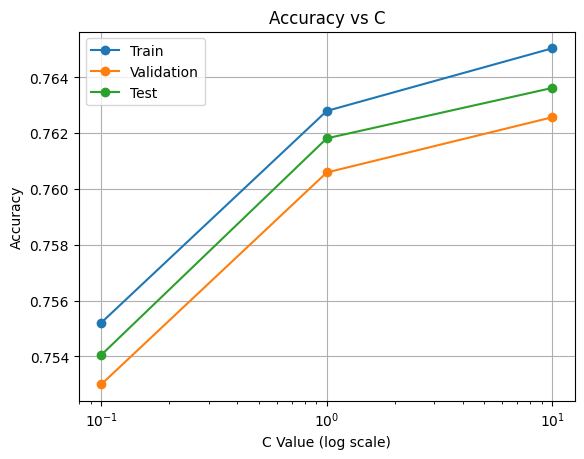

In [9]:
plt.figure()

plt.plot(C_values, train_accs, marker='o', label='Train')
plt.plot(C_values, val_accs, marker='o', label='Validation')
plt.plot(C_values, test_accs, marker='o', label='Test')

plt.xscale('log')
plt.xlabel("C Value (log scale)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs C")
plt.legend()
plt.grid()

plt.show()

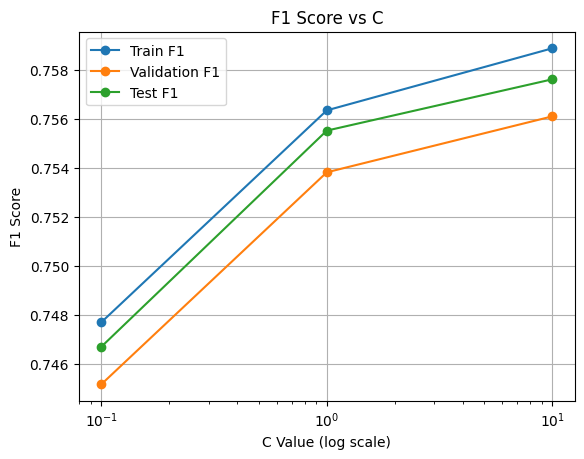

In [10]:
plt.figure()

plt.plot(C_values, train_f1s, marker='o', label='Train F1')
plt.plot(C_values, val_f1s, marker='o', label='Validation F1')
plt.plot(C_values, test_f1s, marker='o', label='Test F1')

plt.xscale('log')
plt.xlabel("C Value (log scale)")
plt.ylabel("F1 Score")
plt.title("F1 Score vs C")
plt.legend()
plt.grid()

plt.show()

In [11]:
y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.76      0.73      0.74     42368
           1       0.77      0.83      0.80     56661
           2       0.75      0.83      0.79      7151
           3       0.76      0.56      0.64       549
           4       0.67      0.11      0.19      1899
           5       0.62      0.44      0.51      3473
           6       0.84      0.70      0.77      4102

    accuracy                           0.76    116203
   macro avg       0.74      0.60      0.63    116203
weighted avg       0.76      0.76      0.76    116203

